# Exemplo de Classificação: Score de créditos


**Suponha que você trabalha em um banco e possui uma base de dados de 100.000 clientes. E nos é dada a tarefa de criar uma classificação de score de créditos, baseados no histórico desses clientes.**


## Importar base de dados

In [ ]:
# Bibliotecas
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Importando dados
df = pd.read_csv('drive/MyDrive/FIESC/Aula01/clientes.csv', sep=',')

df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id_cliente,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,3392,1,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,265.0,21.465380,alto_gasto_pagamento_baixos,312.494089,Good,1,1,1,1,0
1,3392,2,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,266.0,21.465380,baixo_gasto_pagamento_alto,284.629162,Good,1,1,1,1,0
2,3392,3,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,267.0,21.465380,baixo_gasto_pagamento_medio,331.209863,Good,1,1,1,1,0
3,3392,4,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,5.0,...,268.0,21.465380,baixo_gasto_pagamento_baixo,223.451310,Good,1,1,1,1,0
4,3392,5,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,6.0,...,269.0,21.465380,alto_gasto_pagamento_medio,341.489231,Good,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,37932,4,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,23.0,...,378.0,24.028477,alto_gasto_pagamento_alto,479.866228,Poor,1,0,0,0,1
99996,37932,5,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,18.0,...,379.0,24.028477,alto_gasto_pagamento_medio,496.651610,Poor,1,0,0,0,1
99997,37932,6,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,27.0,...,380.0,24.028477,alto_gasto_pagamento_alto,516.809083,Poor,1,0,0,0,1
99998,37932,7,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,20.0,...,381.0,24.028477,baixo_gasto_pagamento_alto,319.164979,Standard,1,0,0,0,1


In [ ]:
df['score_credito'].unique()

array(['Good', 'Standard', 'Poor'], dtype=object)

In [ ]:
# visualizar formato dos dados
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  object 
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  object 
 13  divida_total              100000 non-null  fl

#

# Pré-Processamento

* Nessa etapa fazemos uma limpeza da nossa base de dados.

* Verificamos os tipos dos dados e se tem dados nulos (o que pode ser problemático, ruídos).

* No machine learning (inteligência artificial de modo geral) trabalha com números. Pra conseguir treinar nosso medelo, precisamos realizar uma tratativa, onde transformamos variáveis qualitativas em númericas.

* Informações como: cientista, professor, mecânico... será transformada em números: 0, 1, 2...

* Somente a coluna que será utilizada como output não precisa ser convertida para numérica.

In [ ]:
# Biblioteca sklearn.preprocessing - text > number
from sklearn.preprocessing import LabelEncoder

# vamos usar sklearn.preprocessing para converter as colunas necessárias

labelencoder_profissao = LabelEncoder()
df["profissao"] = labelencoder_profissao.fit_transform(df["profissao"])

labelencoder_mix_credito = LabelEncoder()
df["mix_credito"] = labelencoder_mix_credito.fit_transform(df["mix_credito"])

labelencoder_comportamento_pagamento = LabelEncoder()
df["comportamento_pagamento"] = labelencoder_comportamento_pagamento.fit_transform(df["comportamento_pagamento"])

# Visualizando os formatos dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  int64  
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  int64  
 13  divida_total              100000 non-null  fl

#

In [ ]:
# Em y vamos ter os dados que iremos prever
y = df["score_credito"].copy()

In [ ]:
# Em x temos os dados que serão utilizados para treinar o modelo (id_cliente e score_credito não entram no treinamento)
columns_model = [
    'mes', 'idade', 'profissao', 'salario_anual', 'num_contas',
    'num_cartoes', 'juros_emprestimo', 'num_emprestimos',
    'dias_atraso', 'num_pagamentos_atrasados', 'num_verificacoes_credito',
    'mix_credito', 'divida_total', 'taxa_uso_credito',
    'idade_historico_credito', 'investimento_mensal',
    'comportamento_pagamento', 'saldo_final_mes',
    'emprestimo_carro', 'emprestimo_casa', 'emprestimo_pessoal',
    'emprestimo_credito', 'emprestimo_estudantil'
]

x = df[columns_model].copy()

In [ ]:
# Biblioteca utilizada para separar a base de treino e base de teste
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3)

## Modelos

[Scikit Learn](https://scikit-learn.org/stable/supervised_learning.html)

### Random Forest

# 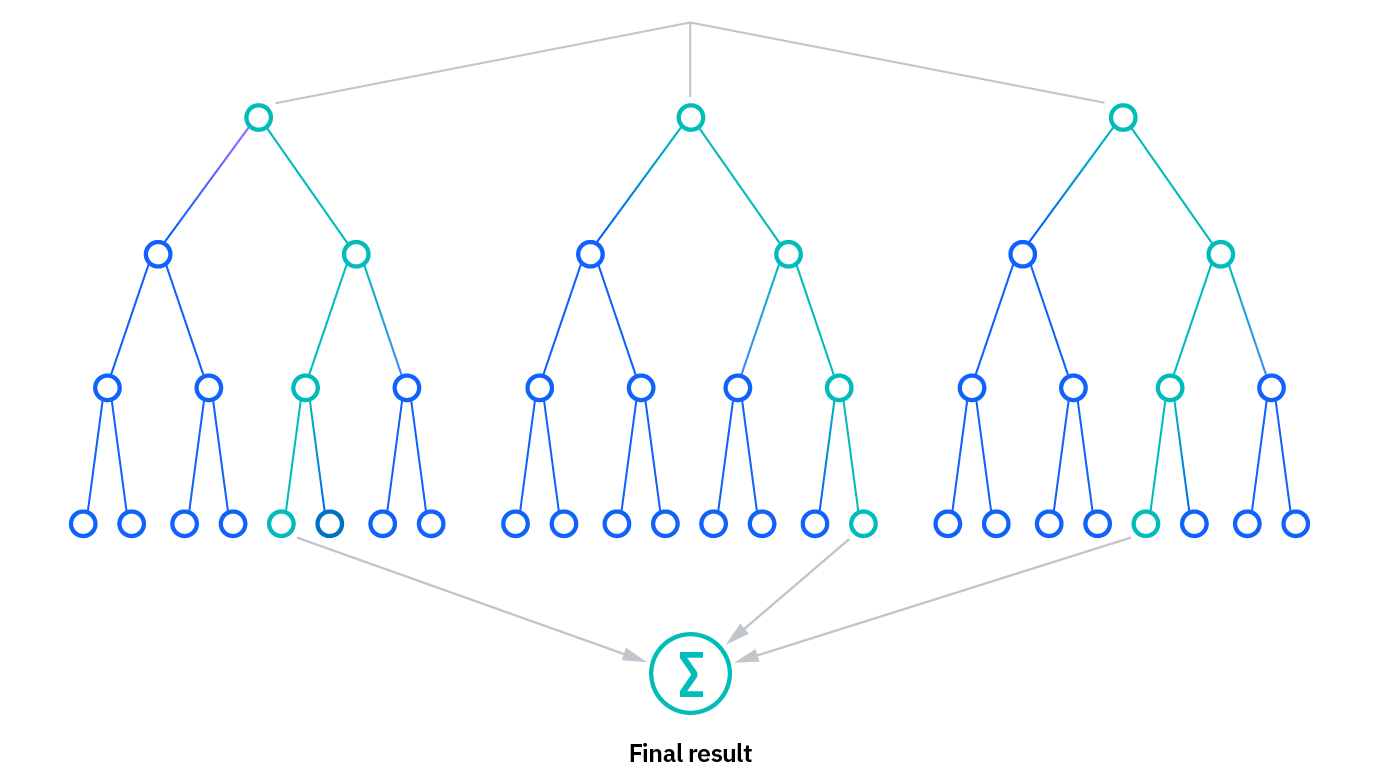

In [ ]:
# RandomForest > Arvore de Decisao
from sklearn.ensemble import RandomForestClassifier

# Criação do modelo
modelo_arvoredecisao = RandomForestClassifier()

# Treinamento
modelo_arvoredecisao.fit(x_treino, y_treino)

RandomForestClassifier()

#

### KNN (K-Nearest Neighbors)

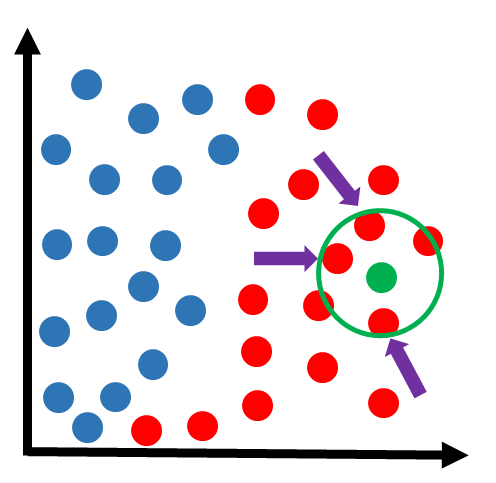

In [ ]:
# Nearest Neighbors (KNN) > Vizinhos Proximos
from sklearn.neighbors import KNeighborsClassifier

# Criação do modelo
modelo_knn = KNeighborsClassifier()

# Treinamento
modelo_knn.fit(x_treino, y_treino)

KNeighborsClassifier()

Vamos usar a base de teste para verificar qual modelo teve o melhor desempenho

In [ ]:
# verificando as previsões com base nos dados de teste
previsao_arvoredecisao = modelo_arvoredecisao.predict(x_teste)
previsao_knn = modelo_knn.predict(x_teste)

In [ ]:
# sklearn.metrics para verificar quão acurado são os modelos
from sklearn.metrics import accuracy_score

print(f'Random Forest ==> {accuracy_score(y_teste, previsao_arvoredecisao)}')
print(f'Nearest Neighbors (KNN) ==> {accuracy_score(y_teste, previsao_knn)}')


Random Forest ==> 0.8234333333333334
Nearest Neighbors (KNN) ==> 0.7362333333333333


Desse modo verificamos que pra esse problema o modelo de arvore de decisão teve o melhor desempenho, para o problema em questão.

Agora podemos usar o melhor modelo para classificar novos clientes

In [ ]:
# novos_clientes
df_novos_clientes = pd.read_csv("drive/MyDrive/FIESC/Aula01/clientesNovos.csv", sep=',')

# Pré processamento
df_novos_clientes["profissao"] = labelencoder_profissao.transform(df_novos_clientes["profissao"])
df_novos_clientes["mix_credito"] = labelencoder_mix_credito.transform(df_novos_clientes["mix_credito"])
df_novos_clientes["comportamento_pagamento"] = labelencoder_comportamento_pagamento.transform(df_novos_clientes["comportamento_pagamento"])

# print visualização
df_novos_clientes

,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,taxa_uso_credito,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,1,31.0,5,19300.340,6.0,7.0,17.0,5.0,52.0,19.0,...,29.934186,218.0,44.50951,4,312.487689,1,1,0,0,0
1,4,32.0,0,12600.445,5.0,5.0,10.0,3.0,25.0,18.0,...,28.819407,12.0,0.00000,5,300.994163,0,0,0,0,1
2,2,48.0,5,20787.690,8.0,6.0,14.0,7.0,24.0,14.0,...,34.235853,215.0,0.00000,3,345.081577,0,1,0,1,0


In [ ]:
# Calculando os score de crédito com base no modelo
score_previsao = modelo_arvoredecisao.predict(df_novos_clientes)
print(score_previsao)

['Poor' 'Poor' 'Standard']


In [ ]:
# Adicionando a coluna com os scores para os novos clientes
df_novos_clientes['score_credito'] = score_previsao
df_novos_clientes

,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil,score_credito
0,1,31.0,5,19300.340,6.0,7.0,17.0,5.0,52.0,19.0,...,218.0,44.50951,4,312.487689,1,1,0,0,0,Poor
1,4,32.0,0,12600.445,5.0,5.0,10.0,3.0,25.0,18.0,...,12.0,0.00000,5,300.994163,0,0,0,0,1,Poor
2,2,48.0,5,20787.690,8.0,6.0,14.0,7.0,24.0,14.0,...,215.0,0.00000,3,345.081577,0,1,0,1,0,Standard
